<a href="https://colab.research.google.com/github/JuanSRVM/TP-LABO-FACU/blob/main/TP_EcommerceDeportivo_FCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico – Exploración, análisis y presentación de datos reales asistida por IA

**Universidad de Buenos Aires · Facultad de Ciencias Económicas**  
Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones  
1er Cuatrimestre 2026

---

## Dataset seleccionado

**Global E-Commerce Dataset (2024–2026)**  
Fuente: [Kaggle – akrambelha/global-e-commerce-dataset-1m-records-20242026](https://www.kaggle.com/datasets/akrambelha/global-e-commerce-dataset-1m-records-20242026)

## Importación de librerías y descarga del dataset

Se importan las librerías necesarias para el análisis y se descarga el dataset directamente desde Kaggle utilizando `kagglehub`.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# Descarga del dataset desde Kaggle
path = kagglehub.dataset_download(
    "akrambelha/global-e-commerce-dataset-1m-records-20242026"
)

print("Path:", path)

100%|██████████| 483M/483M [00:07<00:00, 70.9MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/akrambelha/global-e-commerce-dataset-1m-records-20242026/versions/1


# 3.1 Carga y exploración inicial



Antes de comenzar con el análisis se realizó una exploración general del dataset para conocer su estructura, identificar las variables disponibles y verificar posibles problemas de calidad de datos.

En esta etapa se revisaron las dimensiones del conjunto de datos, los tipos de variables, la existencia de valores nulos y registros duplicados. También se analizaron estadísticas descriptivas básicas para comprender el comportamiento general de las variables numéricas.

A continuación se carga el archivo y se muestran algunas observaciones del dataset.

In [ ]:
# Carga del archivo CSV
archivo = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, archivo))

# Primeras y últimas filas
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000123, 62)


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,...,Email,Mobile,Search,52.1,13,No,45.3,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,...,Google Ads,Desktop,Referral,36.2,15,No,97.1,33.91,Low,Yes
2,ORD-YTJXE,2025-03-17 19:49:36.983317,2025,3,17,19,49,36,No,Completed,...,Facebook,Tablet,Search,43.1,13,No,43.8,52.77,High,No
3,ORD-EIMVI,2024-09-27 06:24:44.913768,2024,9,27,6,24,44,No,Completed,...,Instagram,Mobile,Direct,39.5,18,Yes,96.9,38.15,Low,Yes
4,ORD-OR56F,2025-05-21 17:10:48.401882,2025,5,21,17,10,48,No,Completed,...,Facebook,Tablet,Social,28.0,3,Yes,45.8,33.05,High,Yes


In [ ]:
df.tail()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
1000118,ORD-MH6TM,2024-08-21 19:30:06.902744,2024,8,21,19,30,6,No,Completed,...,Affiliate,Mobile,Search,13.6,1,Yes,99.8,45.23,High,Yes
1000119,ORD-ILXX0,2024-04-05 09:58:34.625191,2024,4,5,9,58,34,No,Cancelled,...,Google Ads,Tablet,Email,30.2,13,No,36.7,49.46,Low,Yes
1000120,ORD-O2H6B,2024-11-09 21:15:09.983331,2024,11,9,21,15,9,Yes,Completed,...,Google Ads,Desktop,Direct,43.4,1,No,51.2,45.83,High,Yes
1000121,ORD-EGD60,2025-10-17 12:48:19.451188,2025,10,17,12,48,19,No,Completed,...,Facebook,Mobile,Email,30.7,9,No,72.4,41.07,High,Yes
1000122,ORD-HBJAD,2025-04-17 15:30:36.405483,2025,4,17,15,30,36,No,Completed,...,Facebook,Desktop,Search,43.2,4,Yes,25.9,42.64,Low,Yes


### Estructura del dataset

Se examinan los tipos de dato de cada columna para identificar posibles inconsistencias (por ejemplo, fechas almacenadas como texto o importes como cadenas de caracteres).

In [ ]:
df.dtypes

,0
order_id,object
order_date,object
order_year,int64
order_month,int64
order_day,int64
...,...
abandoned_cart_before,object
fraud_risk_score,float64
profit_margin_percent,float64
order_priority,object


### Calidad de los datos

Se analizan valores nulos, registros duplicados y estadísticas descriptivas para detectar problemas que puedan afectar el análisis posterior.

In [ ]:
# Valores nulos por columna
print("=== Valores nulos ===")
print(df.isnull().sum())

# Registros duplicados
print("\nDuplicados:", df.duplicated().sum())

=== Valores nulos ===
order_id                  0
order_date                0
order_year                0
order_month               0
order_day                 0
                         ..
abandoned_cart_before     0
fraud_risk_score          0
profit_margin_percent     0
order_priority            0
support_ticket_created    0
Length: 62, dtype: int64

Duplicados: 0


In [ ]:
# Estadísticas descriptivas
df.describe()

,order_year,order_month,order_day,order_hour,order_minute,order_second,age,customer_loyalty_score,total_orders_by_customer,product_rating_avg,...,cost_usd,profit_usd,tax_usd,shipping_cost_usd,delivery_days,rating,session_duration_minutes,pages_visited,fraud_risk_score,profit_margin_percent
count,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,...,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06
mean,2.024590e+03,6.514849e+00,1.575253e+01,1.148814e+01,2.949467e+01,2.948548e+01,4.649414e+01,4.997252e+01,2.548700e+01,3.999194e+00,...,2.423092e+02,1.609270e+02,3.025157e+01,1.250445e+01,7.506648e+00,2.999784e+00,3.051033e+01,1.050609e+01,4.996161e+01,3.946517e+01
std,5.758891e-01,3.448711e+00,8.799790e+00,6.918078e+00,1.730984e+01,1.732781e+01,1.673373e+01,2.889377e+01,1.443421e+01,5.784694e-01,...,2.267157e+02,1.619301e+02,2.889152e+01,7.216416e+00,4.032930e+00,1.414973e+00,1.703368e+01,5.766207e+00,2.884771e+01,1.094131e+01
min,2.024000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.000000e+00,3.000000e+00,...,4.030000e+00,7.000000e-01,4.300000e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,6.660000e+00
25%,2.024000e+03,4.000000e+00,8.000000e+00,5.000000e+00,1.400000e+01,1.400000e+01,3.200000e+01,2.490000e+01,1.300000e+01,3.500000e+00,...,8.245000e+01,5.069000e+01,1.012000e+01,6.260000e+00,4.000000e+00,2.000000e+00,1.570000e+01,6.000000e+00,2.500000e+01,3.169000e+01
50%,2.025000e+03,7.000000e+00,1.600000e+01,1.100000e+01,3.000000e+01,2.900000e+01,4.600000e+01,5.000000e+01,2.500000e+01,4.000000e+00,...,1.725300e+02,1.087900e+02,2.128000e+01,1.250000e+01,8.000000e+00,3.000000e+00,3.050000e+01,1.100000e+01,5.000000e+01,3.990000e+01
75%,2.025000e+03,1.000000e+01,2.300000e+01,1.700000e+01,4.400000e+01,4.400000e+01,6.100000e+01,7.500000e+01,3.800000e+01,4.500000e+00,...,3.264500e+02,2.146400e+02,4.059000e+01,1.874000e+01,1.100000e+01,4.000000e+00,4.530000e+01,1.600000e+01,7.490000e+01,4.817000e+01
max,2.026000e+03,1.200000e+01,3.100000e+01,2.300000e+01,5.900000e+01,5.900000e+01,7.500000e+01,1.000000e+02,5.000000e+01,5.000000e+00,...,1.743700e+03,1.495750e+03,2.455900e+02,2.500000e+01,1.400000e+01,5.000000e+00,6.000000e+01,2.000000e+01,1.000000e+02,6.002000e+01


### Observaciones

A partir de la exploración inicial se observó que el dataset contiene aproximadamente un millón de registros correspondientes a transacciones de comercio electrónico realizadas entre 2024 y 2026.

Se detectaron valores faltantes en algunas variables vinculadas a reseñas, devoluciones y promociones. Estos casos no representan necesariamente errores de carga, ya que no todas las compras reciben una valoración ni participan de campañas promocionales.

Por otro lado, no se encontraron registros duplicados relevantes ni inconsistencias que impidieran continuar con el análisis.

# 3.2 Pregunta de investigación



### a) ¿Cuál es la pregunta?

> **¿Cuál sería el costo estimado de equipar un gimnasio utilizando productos de las categorías *Sports* y *Health* comercializados durante los años 2024 y 2025?**

### b) ¿Por qué vale la pena responderla?

La apertura o renovación de un gimnasio requiere inversiones significativas en equipamiento. Conocer el costo estimado de los principales productos asociados a la actividad física permite **dimensionar la inversión necesaria** utilizando precios reales de mercado, en lugar de estimaciones genéricas.

### c) ¿Qué respuesta encontraron?

El análisis permitió estimar que equipar un gimnasio con los 15 productos seleccionados requiere una inversión aproximada de USD 1.794, considerando una unidad de cada artículo al precio promedio observado entre 2024 y 2025. Un hallazgo destacado es que los precios unitarios son llamativamente homogéneos entre todos los productos y subcategorías, situándose en un rango de USD 131 a USD 134, sin diferencias significativas entre categorías ni entre marcas. En consecuencia, la inversión total depende principalmente de la cantidad de artículos adquiridos y no del tipo de producto elegido, lo que simplifica la planificación presupuestaria para quien desee equipar un gimnasio.

# 3.3 Transformaciones y resumen estadístico

### Criterios de selección

Con el objetivo de responder la pregunta de investigación se aplicaron distintos filtros sobre el conjunto de datos.

Estos filtros permitieron conservar únicamente las observaciones relevantes para estimar el costo de equipar un gimnasio utilizando productos comercializados dentro de las categorías Sports y Health.

In [ ]:
# Filtro 1: categorías relevantes
df_filtrado = df[df["category"].isin(["Health", "Sports"])].copy()
print("Luego del filtro de categorías:", len(df_filtrado))

# Filtro 2: solo compras completadas
df_filtrado = df_filtrado[df_filtrado["order_status"] == "Completed"].copy()
print("Luego del filtro de órdenes completadas:", len(df_filtrado))

# Filtro 3: período de análisis
df_filtrado = df_filtrado[df_filtrado["order_year"].isin([2024, 2025])].copy()
print("Luego del filtro temporal:", len(df_filtrado))

Luego del filtro de categorías: 399971
Luego del filtro de órdenes completadas: 279912
Luego del filtro temporal: 267302


La selección se realizó considerando aquellos artículos que podrían formar parte del equipamiento habitual de un gimnasio o complementar la actividad física de sus usuarios. Los productos restantes fueron excluidos debido a que no aportaban información relevante para la estimación buscada.

In [ ]:
productos_gimnasio = [
    "Foam Roller",
    "Gym Gloves",
    "Resistance Bands Set",
    "Swimming Goggles",
    "Vitamin C Tablets",
    "Massage Gun Deep Tissue",
    "Protein Shaker Bottle",
    "Fitness Smart Band",
    "Water Bottle Insulated",
    "Jump Rope Speed",
    "Dumbbells Set Adjustable",
    "Yoga Mat Non-Slip",
    "Exercise Ball",
    "Treadmill Folding",
    "Tennis Balls Pack"
]

df_filtrado = df_filtrado[df_filtrado["product_name"].isin(productos_gimnasio)].copy()
print("Registros finales:", len(df_filtrado))

Registros finales: 222743


### Configuración de estilo para los gráficos

Se define una paleta de colores por sub-categoría para mantener consistencia visual en los tres gráficos que se producirán a continuación.

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.05)

PALETTE = {
    "Gym Equipment":   "#5DCAA5",
    "Fitness":         "#7F77DD",
    "Accessories":     "#FAC775",
    "Personal Care":   "#D85A30",
    "Outdoor":         "#AFA9EC",
    "Sports Wear":     "#888780",
    "Medical Devices": "#F09595",
    "Supplements":     "#378ADD",
}

### Agrupación por producto

Se realiza una primera agrupación por producto para identificar:
- cuáles son los artículos más vendidos,
- su precio promedio, y
- el volumen de ingresos y ganancia generados.

Esta tabla permite comprender el peso relativo de cada producto dentro de la inversión total necesaria para equipar el gimnasio.

In [ ]:
resumen_productos = (
    df_filtrado
    .groupby("product_name")
    .agg(
        ventas=("order_id", "count"),
        precio_promedio=("unit_price_usd", "mean"),
        ingresos_totales=("total_price_usd", "sum"),
        ganancia_total=("profit_usd", "sum")
    )
    .round(2)
    .sort_values("ingresos_totales", ascending=False)
)

resumen_productos

,ventas,precio_promedio,ingresos_totales,ganancia_total
product_name,,,,
Gym Gloves,14973,132.91,5489493.62,2195053.38
Water Bottle Insulated,15186,131.78,5483478.28,2187229.86
Tennis Balls Pack,14909,133.29,5470166.62,2186558.56
Treadmill Folding,14969,132.00,5440598.88,2165386.12
Jump Rope Speed,14870,132.15,5396463.87,2149484.44
Swimming Goggles,14825,132.21,5366029.05,2146419.49
Exercise Ball,14712,132.24,5362517.11,2153411.50
Dumbbells Set Adjustable,14719,132.09,5312736.44,2134289.18
Foam Roller,15036,105.45,4352392.01,1740108.13


### Agrupación por año

Se realiza una segunda agrupación para comparar el volumen de ventas, ingresos y ganancia entre **2024 y 2025**. Esta comparación permite identificar si existe una tendencia de crecimiento o contracción en el mercado de productos de gimnasio durante el período analizado.

In [ ]:
resumen_anual = (
    df_filtrado
    .groupby("order_year")
    .agg(
        ventas=("order_id", "count"),
        ingresos=("total_price_usd", "sum"),
        ganancia=("profit_usd", "sum")
    )
    .round(2)
)

resumen_anual

,ventas,ingresos,ganancia
order_year,,,
2024,106286,34891515.51,13936764.68
2025,116457,38260822.84,15292385.12


# 3.4 Análisis gráfico

### Uso de Inteligencia Artificial

Para la construcción de las visualizaciones se utilizó asistencia de Inteligencia Artificial como apoyo en la generación inicial del código y en la adaptación de ciertos elementos gráficos.

Posteriormente, los gráficos fueron revisados, ajustados e interpretados por los integrantes del grupo para asegurar su adecuación a los objetivos del análisis.

prompt: Actuá como un analista de datos senior especializado en visualización. Tengo un dataset de e-commerce filtrado por las categorías Sports y Health, con las columnas: sub_category, unit_price_usd, brand, order_year, order_month, total_price_usd, profit_usd. Necesito tres gráficos en Python con matplotlib y seaborn: (a) un boxplot de distribución de precios por sub-categoría, (b) un gráfico de barras apiladas con precio promedio por sub-categoría según las 4 marcas más vendidas, y (c) un gráfico de líneas con la evolución mensual del precio promedio por marca. Usá una paleta de colores consistente definida como diccionario. Cada gráfico debe tener título, etiquetas en ambos ejes.

### a) Distribución de precios por sub-categoría (Boxplot)

Este gráfico muestra la dispersión del precio unitario (USD) dentro de cada sub-categoría presente en el dataset filtrado.

- **Caja:** rango intercuartílico (Q1–Q3).
- **Línea central:** mediana.
- **Puntos naranjas:** valores atípicos (*outliers*).

| Sub-categoría | Descripción |
|---|---|
| Gym Equipment | Equipamiento principal (mancuernas, cinta, etc.) |
| Fitness | Accesorios de ejercicio (bandas, colchoneta, etc.) |
| Accessories | Complementos (botella, guantes, etc.) |
| Personal Care | Cuidado personal (shaker, vitaminas, etc.) |
| Outdoor | Equipamiento exterior (soga, pelotas, etc.) |
| Medical Devices | Dispositivos de salud (foam roller, etc.) |
| Supplements | Suplementos nutricionales |
| Sports Wear | Indumentaria deportiva |

**Lectura:** las sub-categorías con cajas más altas y anchas presentan mayor variabilidad de precios, lo que implica más opciones disponibles para distintos presupuestos.

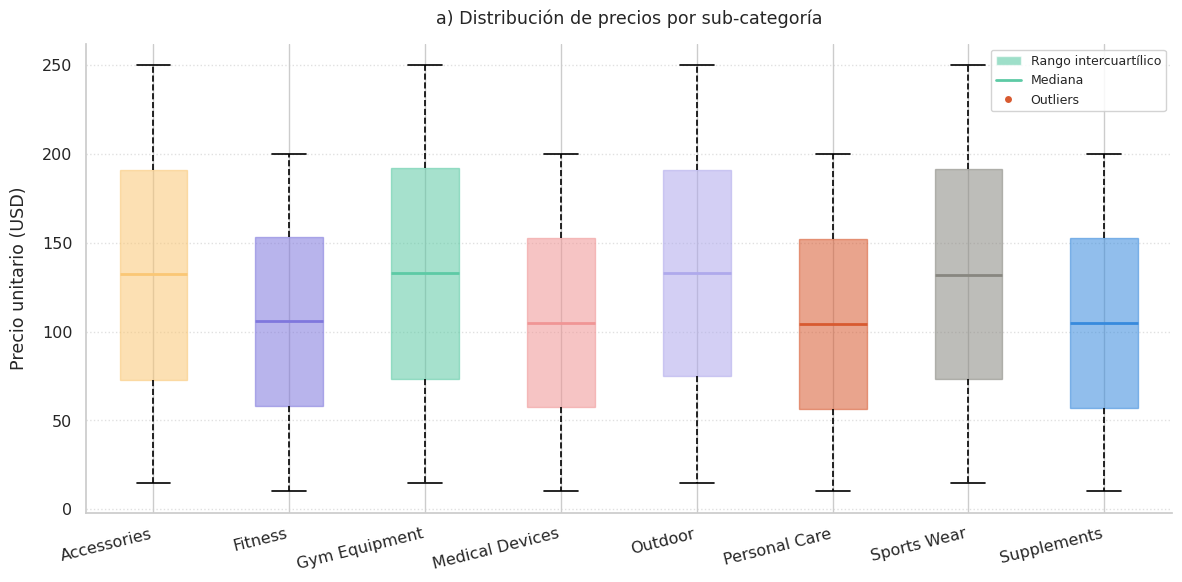

Gráfico A guardado.


In [ ]:
fig_a, ax_a = plt.subplots(figsize=(12, 6))

subcats = sorted(df_filtrado["sub_category"].dropna().unique())
colors  = [PALETTE.get(s, "#B4B2A9") for s in subcats]

data_box = [
    df_filtrado.loc[df_filtrado["sub_category"] == s, "unit_price_usd"].dropna().values
    for s in subcats
]

bp = ax_a.boxplot(
    data_box,
    patch_artist=True,
    medianprops=dict(linewidth=2),
    flierprops=dict(marker="o", markersize=4,
                    markerfacecolor="#D85A30", markeredgecolor="white",
                    linewidth=0.5),
    whiskerprops=dict(linestyle="--", linewidth=1.2),
    capprops=dict(linewidth=1.2),
    widths=0.5,
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
    patch.set_edgecolor(color)

for median, color in zip(bp["medians"], colors):
    median.set_color(color)

ax_a.set_xticks(range(1, len(subcats) + 1))
ax_a.set_xticklabels(subcats, rotation=14, ha="right")
ax_a.set_ylabel("Precio unitario (USD)", labelpad=10)
ax_a.set_title("a) Distribución de precios por sub-categoría", pad=14, weight="medium")
ax_a.grid(axis="y", linestyle=":", alpha=0.6)
ax_a.spines[["top", "right"]].set_visible(False)

patches_leg = [
    mpatches.Patch(facecolor="#5DCAA5", alpha=0.6, label="Rango intercuartílico"),
    plt.Line2D([0], [0], color="#5DCAA5", lw=2, label="Mediana"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#D85A30",
               markersize=6, label="Outliers"),
]
ax_a.legend(handles=patches_leg, loc="upper right", framealpha=0.85, fontsize=9)

plt.tight_layout()
plt.savefig("grafico_a_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico A guardado.")

**Interpretación:** La distribución de precios presenta un comportamiento relativamente homogéneo entre las distintas sub-categorías analizadas. Las categorías Accessories, Gym Equipment, Outdoor y Sports Wear exhiben medianas de precio superiores al resto, ubicándose en torno a los USD 130. Asimismo, la amplitud de los rangos intercuartílicos indica una elevada dispersión de precios dentro de cada sub-categoría, lo que sugiere la coexistencia de productos de diferentes niveles de calidad y posicionamiento comercial. La ausencia de diferencias extremas entre categorías permite inferir que el precio promedio no depende exclusivamente de la sub-categoría, sino también de otros factores como la marca o las características específicas de cada producto.

### b) Precio promedio por sub-categoría según marca (Barras apiladas)

Este gráfico muestra el precio promedio (USD) aportado por cada una de las **4 marcas con mayor volumen de ventas** dentro del dataset filtrado, desagregado por sub-categoría.

**Lectura:** la altura total de cada barra representa el precio promedio acumulado de esa sub-categoría considerando las marcas más vendidas. Las marcas en la parte inferior de la barra son las que mayor peso tienen en ese segmento del mercado.

/tmp/ipykernel_2545/1283657327.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_b.set_xticklabels(df_b.index, rotation=14, ha="right")


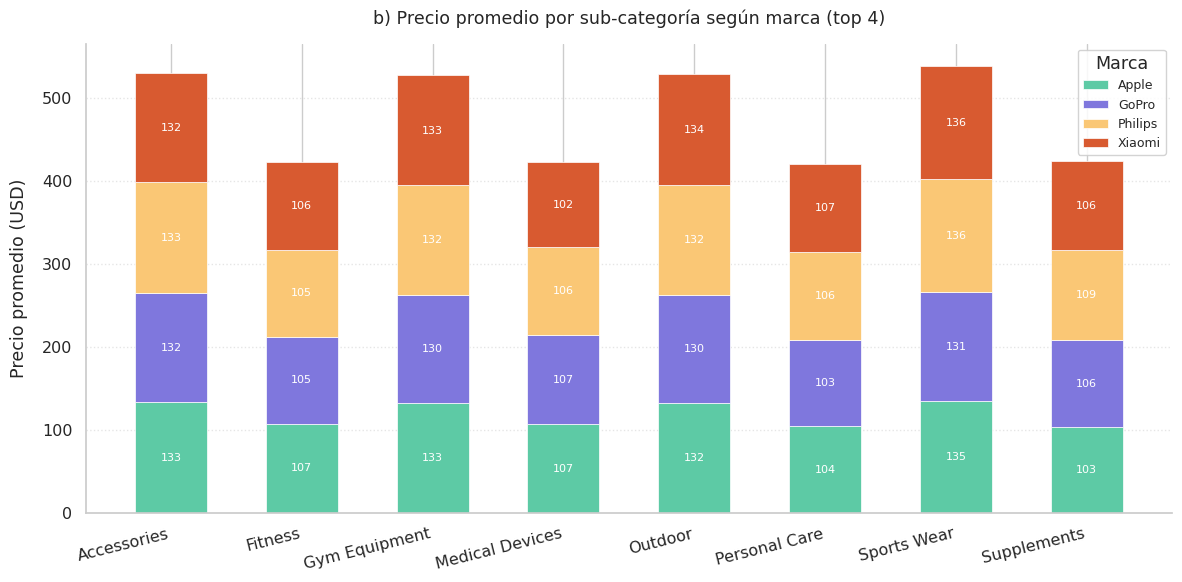

Gráfico B guardado.


In [ ]:
# Selección de las 4 marcas con mayor volumen de ventas
top_marcas = (
    df_filtrado.groupby("brand")["order_id"]
    .count()
    .nlargest(4)
    .index.tolist()
)

MARCA_COLORS = [
    PALETTE["Gym Equipment"],
    PALETTE["Fitness"],
    PALETTE["Accessories"],
    PALETTE["Personal Care"],
]

# Precio promedio por sub-categoría y marca (solo top 4)
df_b = (
    df_filtrado[df_filtrado["brand"].isin(top_marcas)]
    .groupby(["sub_category", "brand"])["unit_price_usd"]
    .mean()
    .round(2)
    .unstack(fill_value=0)
)

marca_colors = MARCA_COLORS

fig_b, ax_b = plt.subplots(figsize=(12, 6))
bottoms = np.zeros(len(df_b))

for j, marca in enumerate(df_b.columns):
    vals = df_b[marca].values
    bars = ax_b.bar(
        df_b.index, vals, bottom=bottoms,
        color=marca_colors[j % len(marca_colors)],
        label=marca, width=0.55,
        edgecolor="white", linewidth=0.5
    )
    # Etiqueta de valor dentro de cada segmento (solo si es suficientemente alto)
    for bar, v, bot in zip(bars, vals, bottoms):
        if v > 10:
            ax_b.text(
                bar.get_x() + bar.get_width() / 2,
                bot + v / 2,
                f"{v:.0f}", ha="center", va="center",
                fontsize=8, color="white", weight="medium"
            )
    bottoms += vals

ax_b.set_ylabel("Precio promedio (USD)", labelpad=10)
ax_b.set_title("b) Precio promedio por sub-categoría según marca (top 4)", pad=14, weight="medium")
ax_b.set_xticklabels(df_b.index, rotation=14, ha="right")
ax_b.legend(loc="upper right", framealpha=0.85, fontsize=9, title="Marca")
ax_b.spines[["top", "right"]].set_visible(False)
ax_b.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("grafico_b_barras_apiladas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico B guardado.")

Interpretación: Se observa que las cuatro marcas analizadas presentan niveles de precios promedio similares dentro de cada sub-categoría. Sin embargo, las categorías Sports Wear, Accessories, Gym Equipment y Outdoor concentran los mayores valores promedio acumulados, mientras que Fitness, Medical Devices, Personal Care y Supplements registran niveles relativamente inferiores. Esto sugiere que los productos vinculados al equipamiento deportivo y la indumentaria representan segmentos de mayor valor económico dentro del conjunto analizado. Además, la similitud entre marcas indica que la categoría del producto parece tener una mayor influencia sobre el precio promedio que la marca en sí misma.

### c) Evolución del precio promedio mensual por marca

Este gráfico muestra la evolución del **precio unitario promedio (USD)** de las cuatro marcas con mayor volumen de ventas dentro del conjunto de datos filtrado. Cada línea representa una marca y permite observar cómo varían sus precios promedio a lo largo del tiempo.

**Elementos destacados del gráfico:**

- **Cada línea representa una marca** incluida entre las cuatro más vendidas.
- **Los puntos marcan el promedio mensual** del precio unitario.
- **La flecha vertical identifica el mes con mayor dispersión de precios** entre las marcas analizadas.
- **La línea vertical punteada separa los años 2024 y 2025** para facilitar la comparación temporal.

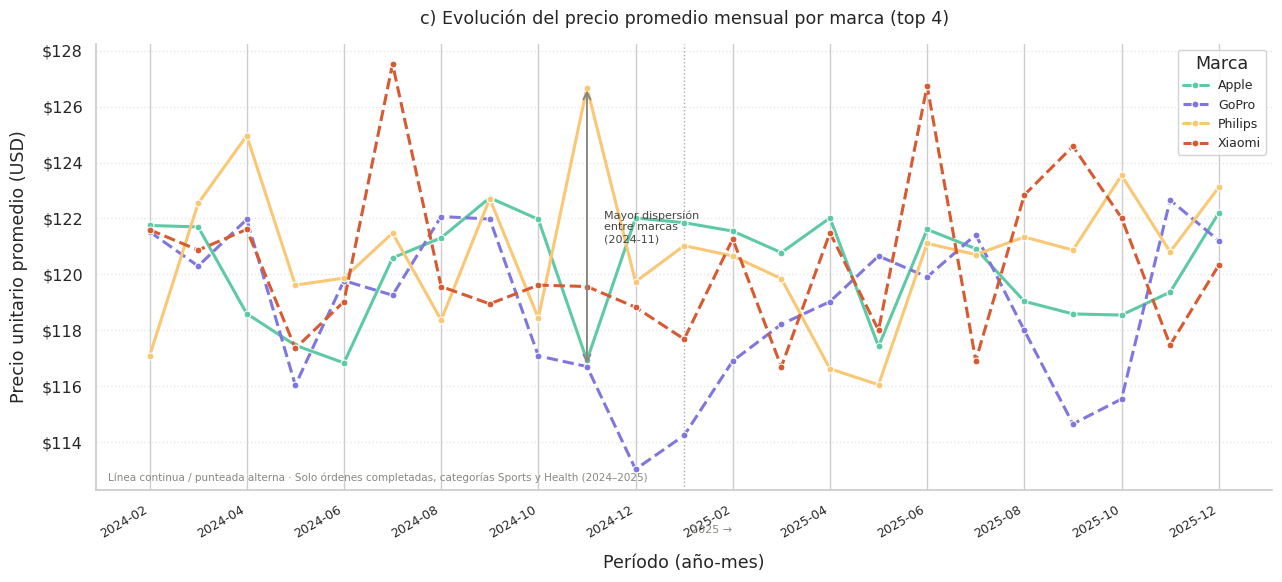

Gráfico C guardado.

Mes de mayor dispersión: 2024-11
Diferencia entre marcas: $9.97 USD


In [ ]:
PALETTE_MARCAS = ["#5DCAA5", "#7F77DD", "#FAC775", "#D85A30"]

# 1. Top 4 marcas por volumen de ventas
top_marcas = (
    df_filtrado
    .groupby("brand")["order_id"]
    .count()
    .nlargest(4)
    .index
    .tolist()
)

# 2. Serie temporal: precio promedio mensual por marca
df_c = df_filtrado[df_filtrado["brand"].isin(top_marcas)].copy()
df_c["periodo"] = (
    df_c["order_year"].astype(str)
    + "-"
    + df_c["order_month"].astype(str).str.zfill(2)
)

serie_temporal = (
    df_c
    .groupby(["periodo", "brand"])["unit_price_usd"]
    .mean()
    .round(2)
    .unstack("brand")
    .sort_index()
)

periodos    = serie_temporal.index.tolist()
xtick_pos   = list(range(0, len(periodos), 2))
xtick_labels = [periodos[i] for i in xtick_pos]

# 3. Figura
fig_c, ax_c = plt.subplots(figsize=(13, 6))

for j, marca in enumerate(serie_temporal.columns):
    ax_c.plot(
        range(len(periodos)),
        serie_temporal[marca],
        color=PALETTE_MARCAS[j],
        linewidth=2.2,
        linestyle="-" if j % 2 == 0 else "--",
        marker="o", markersize=5,
        markeredgecolor="white", markeredgewidth=0.8,
        label=marca, zorder=3,
    )

# 4. Anotación: mes con mayor dispersión
spreads        = serie_temporal.max(axis=1) - serie_temporal.min(axis=1)
idx_max_spread = spreads.idxmax()
pos_max        = periodos.index(idx_max_spread)
y_max          = serie_temporal.loc[idx_max_spread].max()
y_min          = serie_temporal.loc[idx_max_spread].min()

ax_c.annotate(
    "", xy=(pos_max, y_min), xytext=(pos_max, y_max),
    arrowprops=dict(arrowstyle="<->", color="#888780", lw=1.4),
)
ax_c.text(
    pos_max + 0.35, (y_max + y_min) / 2,
    f"Mayor dispersión\nentre marcas\n({idx_max_spread})",
    fontsize=8, color="#444441", va="center",
)

# 5. Separador de años
if "2025-01" in periodos:
    sep_pos = periodos.index("2025-01")
    ax_c.axvline(sep_pos, color="#AAAAAA", linewidth=1, linestyle=":", zorder=1)
    ax_c.text(sep_pos + 0.15,
              serie_temporal.min().min() * 0.98,
              "2025 →", fontsize=8, color="#888780")

# 6. Formato
ax_c.set_xticks(xtick_pos)
ax_c.set_xticklabels(xtick_labels, rotation=30, ha="right", fontsize=9)
ax_c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax_c.set_xlabel("Período (año-mes)", labelpad=10)
ax_c.set_ylabel("Precio unitario promedio (USD)", labelpad=10)
ax_c.set_title("c) Evolución del precio promedio mensual por marca (top 4)",
               pad=14, weight="medium")
ax_c.legend(loc="upper right", framealpha=0.85, fontsize=9, title="Marca")
ax_c.spines[["top", "right"]].set_visible(False)
ax_c.grid(axis="y", linestyle=":", alpha=0.5, zorder=0)
ax_c.text(0.01, 0.02,
          "Línea continua / punteada alterna · Solo órdenes completadas, "
          "categorías Sports y Health (2024–2025)",
          transform=ax_c.transAxes, fontsize=7.5, color="#888780")

plt.tight_layout()
plt.savefig("grafico_c_lineas_marca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico C guardado.")

# Diferencia de precio en el momento de mayor dispersión
print(f"\nMes de mayor dispersión: {idx_max_spread}")
print(f"Diferencia entre marcas: ${spreads[idx_max_spread]:.2f} USD")

Interpretación: Los precios promedio de las principales marcas se mantuvieron relativamente estables durante el período analizado, con variaciones mensuales moderadas y sin tendencias marcadas de aumento o disminución. Esto sugiere que el costo de los productos necesarios para equipar un gimnasio no sufrió cambios significativos entre 2024 y 2025. Además, las diferencias de precio entre marcas suelen ser reducidas, por lo que la elección de una marca u otra tendría un impacto limitado sobre la inversión total estimada. En consecuencia, para este conjunto de productos, el costo de equipamiento parece estar más asociado al tipo de artículo adquirido que a fluctuaciones temporales o diferencias entre marcas.

# 3.5 Aplicación de conceptos de la materia: Margen y Rentabilidad
### Uso de Inteligencia Artificial

Para la implementación del modelo de análisis de rentabilidad y punto de equilibrio se utilizó asistencia de Inteligencia Artificial en la generación inicial del código.

Las fórmulas, cálculos y resultados obtenidos fueron posteriormente revisados y validados por los integrantes del grupo.
## Objetivo

Para responder a la pregunta de investigación *"¿Cuánto cuesta equipar un gimnasio?"*, resulta relevante analizar no solo los costos asociados a cada categoría de equipamiento, sino también su nivel de rentabilidad.

En esta sección se calcula el beneficio total, el margen de ganancia y la participación de cada categoría dentro del beneficio global. Esto permite identificar qué tipos de productos generan una mayor contribución económica y cuáles presentan una rentabilidad relativamente menor.

## Metodología

Se utilizarán las siguientes métricas:

- **Ingresos Totales (IT):** suma del valor total de ventas.
- **Costos Totales (CT):** suma de los costos asociados a los productos vendidos.
- **Beneficio Total:** diferencia entre ingresos y costos.
- **Margen de Rentabilidad (%):** porcentaje de beneficio sobre ingresos.
- **Participación en el Beneficio (%):** contribución de cada categoría al beneficio total generado.

El análisis se realizará agrupando los productos por categoría de equipamiento.

Prompt: Actuá como un analista de datos senior con conocimientos de microeconomía. Tengo un dataset de ventas de e-commerce con las columnas total_price_usd, cost_usd, profit_usd, quantity y sub_category. Necesito implementar en Python una función documentada con docstring que, dado un DataFrame, calcule por sub-categoría: ingresos totales (IT), costos totales (CT), beneficio, margen de rentabilidad porcentual, participación porcentual en el beneficio total, precio promedio, costo promedio, costos fijos estimados (20% del CT) y punto de equilibrio en unidades. Luego, graficá IT, CT y beneficio como barras agrupadas, mostrando el margen sobre cada barra de beneficio. Respondé en español.

In [ ]:
def rentabilidad_por_categoria(df):
    """
    Calcula indicadores de rentabilidad agrupados por categoría.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset con información de ventas.

    Returns
    -------
    pandas.DataFrame
        Tabla con:
        - ingresos totales
        - costos totales
        - beneficio total
        - margen porcentual
        - participación porcentual del beneficio
    """

    resumen = (
        df.groupby("sub_category")
        .agg(
            ingresos=("total_price_usd", "sum"),
            costos=("cost_usd", "sum"),
            beneficio=("profit_usd", "sum")
        )
        .reset_index()
    )

    resumen["margen_pct"] = (
        resumen["beneficio"] /
        resumen["ingresos"] * 100
    ).round(2)

    beneficio_total = resumen["beneficio"].sum()

    resumen["participacion_pct"] = (
        resumen["beneficio"] /
        beneficio_total * 100
    ).round(2)

    return resumen.sort_values(
        by="beneficio",
        ascending=False
    )

**⚠️ Supuesto simplificador:** el dataset no desagrega costos fijos de costos variables (solo provee cost_usd como costo total por orden). Para poder estimar el punto de equilibrio se asume que el 20% del costo total representa costos fijos, valor adoptado de forma arbitraria como aproximación ilustrativa. Este supuesto no surge de los datos y debe interpretarse con cautela.





TABLA RESUMEN — Funciones de costo e ingreso por sub-categoría
                          IT          CT   beneficio  margen_pct  precio_prom  costo_prom  CF_estimado  Q_equilibrio
sub_category                                                                                                        
Accessories      10949292.46  6573689.60  4375602.86       39.96       120.80       72.52   1314737.92       27232.0
Gym Equipment    10830733.91  6492124.28  4338609.63       40.06       121.30       72.71   1298424.86       26722.0
Sports Wear      10769547.18  6464073.93  4305473.25       39.98       120.95       72.60   1292814.79       26739.0
Outdoor          10771910.32  6473763.53  4298146.79       39.90       121.68       73.13   1294752.71       26668.0
Fitness           7493968.92  4497161.78  2996807.14       39.99        96.96       58.18    899432.36       23193.0
Medical Devices   7484264.34  4490208.27  2994056.07       40.00        96.08       57.64    898041.65       23362.0
P

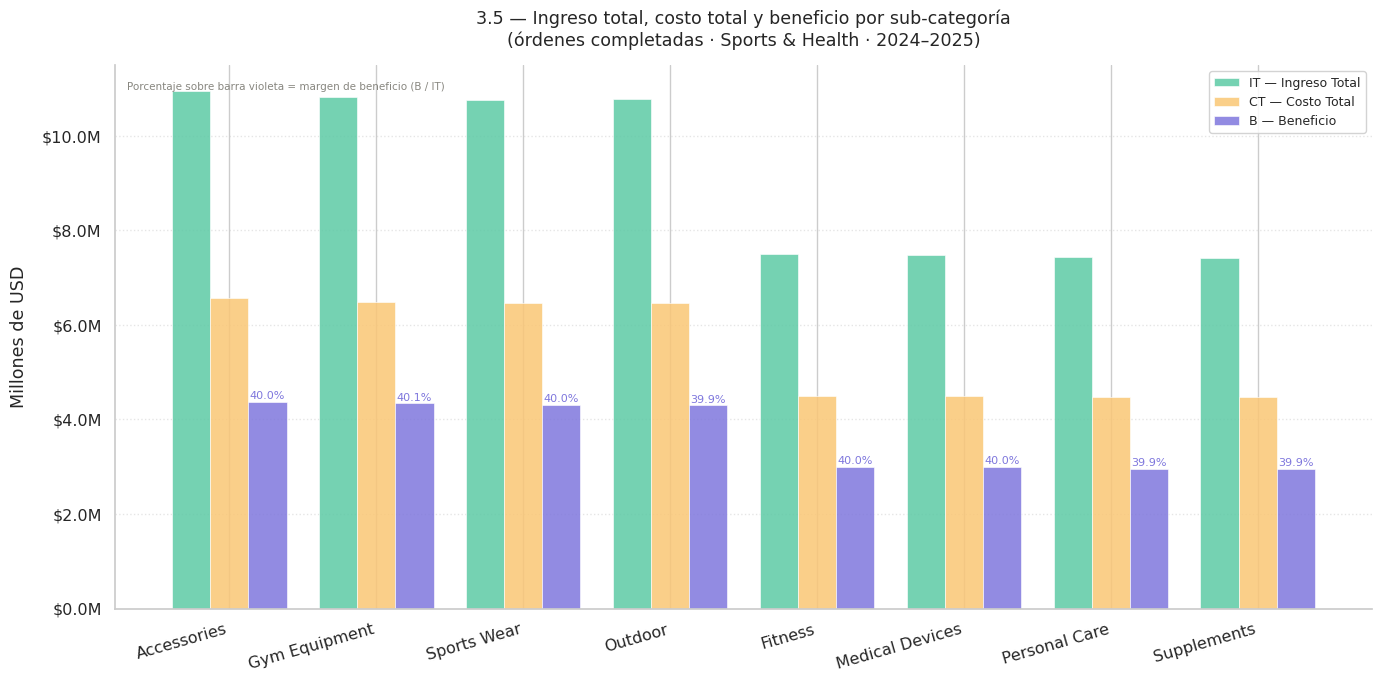

Gráfico 3.5 guardado.


PUNTO DE EQUILIBRIO — unidades mínimas para cubrir costos fijos (CF ≈ 20% CT)
                 p̄ (USD)  c̄ (USD)  CF est. (USD)  Q* (unidades)
sub_category                                                     
Accessories        120.80     72.52     1314737.92        27232.0
Gym Equipment      121.30     72.71     1298424.86        26722.0
Sports Wear        120.95     72.60     1292814.79        26739.0
Outdoor            121.68     73.13     1294752.71        26668.0
Fitness             96.96     58.18      899432.36        23193.0
Medical Devices     96.08     57.64      898041.65        23362.0
Personal Care       95.48     57.42      893338.39        23472.0
Supplements         96.14     57.82      893095.04        23306.0
Inversión estimada (1 unidad por producto):
USD 1,794.00


In [ ]:
# Colores reutilizados del trabajo
COLOR_INGRESOS = PALETTE["Gym Equipment"]
COLOR_COSTOS = PALETTE["Accessories"]
COLOR_BENEFICIO = PALETTE["Fitness"]
COLOR_NEUTRO = PALETTE["Sports Wear"]

# Función principal

def analizar_costo_ingreso(df, grupo="sub_category"):
    """
    Calcula indicadores de ingresos, costos, beneficio y punto de equilibrio
    agrupando la información por la variable seleccionada.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset filtrado con información de ventas.
    grupo : str
        Variable utilizada para agrupar los datos.

    Retorna
    -------
    pandas.DataFrame
        Tabla resumen con ventas, ingresos, costos, beneficio,
        margen de rentabilidad y punto de equilibrio estimado.
    """


    resumen = (
        df.groupby(grupo)
        .agg(
            ventas=("order_id", "count"),
            Q_total=("quantity", "sum"),
            IT=("total_price_usd", "sum"),
            CT=("cost_usd", "sum"),
            beneficio=("profit_usd", "sum"),
        )
        .round(2)
    )

    resumen["precio_prom"] = (
        resumen["IT"] / resumen["Q_total"]
    ).round(2)

    resumen["costo_prom"] = (
        resumen["CT"] / resumen["Q_total"]
    ).round(2)

    resumen["margen_pct"] = (
        resumen["beneficio"] / resumen["IT"] * 100
    ).round(2)

    resumen["CF_estimado"] = (
        resumen["CT"] * 0.20
    ).round(2)

    margen_contribucion = (
        resumen["precio_prom"] - resumen["costo_prom"]
    )

    resumen["Q_equilibrio"] = (
        resumen["CF_estimado"] / margen_contribucion
    ).replace([np.inf, -np.inf], np.nan).round(0)

    return resumen.sort_values(
        "beneficio",
        ascending=False
    )


# Aplicación al dataset

tabla_resumen = analizar_costo_ingreso(
    df_filtrado,
    grupo="sub_category"
)

print("=" * 70)
print("TABLA RESUMEN — Funciones de costo e ingreso por sub-categoría")
print("=" * 70)

print(
    tabla_resumen[
        [
            "IT",
            "CT",
            "beneficio",
            "margen_pct",
            "precio_prom",
            "costo_prom",
            "CF_estimado",
            "Q_equilibrio",
        ]
    ].to_string()
)


# Gráfico: Ingreso total, costo total y beneficio

subcats = tabla_resumen.index.tolist()

x = np.arange(len(subcats))
ancho = 0.26

fig, ax = plt.subplots(figsize=(14, 7))

bars_IT = ax.bar(
    x - ancho,
    tabla_resumen["IT"] / 1e6,
    ancho,
    color=COLOR_INGRESOS,
    label="IT — Ingreso Total",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)

bars_CT = ax.bar(
    x,
    tabla_resumen["CT"] / 1e6,
    ancho,
    color=COLOR_COSTOS,
    label="CT — Costo Total",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)

bars_B = ax.bar(
    x + ancho,
    tabla_resumen["beneficio"] / 1e6,
    ancho,
    color=COLOR_BENEFICIO,
    label="B — Beneficio",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)

# Etiquetas de margen

for bar, margen in zip(bars_B, tabla_resumen["margen_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{margen:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color=COLOR_BENEFICIO,
        weight="medium",
    )

ax.set_xticks(x)
ax.set_xticklabels(
    subcats,
    rotation=16,
    ha="right"
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, _: f"${v:.1f}M"
    )
)

ax.set_ylabel(
    "Millones de USD",
    labelpad=10
)

ax.set_title(
    "3.5 — Ingreso total, costo total y beneficio por sub-categoría\n"
    "(órdenes completadas · Sports & Health · 2024–2025)",
    pad=14,
    weight="medium",
)

ax.legend(
    framealpha=0.85,
    fontsize=9
)

ax.spines[["top", "right"]].set_visible(False)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

ax.text(
    0.01,
    0.97,
    "Porcentaje sobre barra violeta = margen de beneficio (B / IT)",
    transform=ax.transAxes,
    fontsize=7.5,
    color=COLOR_NEUTRO,
    va="top",
)

plt.tight_layout()

plt.savefig(
    "seccion35_IT_CT_beneficio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Gráfico 3.5 guardado.")


# Punto de equilibrio

print("\n")
print("=" * 70)
print(
    "PUNTO DE EQUILIBRIO — unidades mínimas para cubrir costos fijos (CF ≈ 20% CT)"
)
print("=" * 70)

print(
    tabla_resumen[
        [
            "precio_prom",
            "costo_prom",
            "CF_estimado",
            "Q_equilibrio",
        ]
    ]
    .rename(
        columns={
            "precio_prom": "p̄ (USD)",
            "costo_prom": "c̄ (USD)",
            "CF_estimado": "CF est. (USD)",
            "Q_equilibrio": "Q* (unidades)",
        }
    )
    .to_string()
)

print("Inversión estimada (1 unidad por producto):")
print(f"USD {resumen_productos['precio_promedio'].sum():,.2f}")

Interpretación: Los resultados muestran que las subcategorías Accessories, Gym Equipment, Sports Wear y Outdoor generan los mayores niveles de ingresos, costos y beneficios totales dentro del conjunto analizado. Esto indica que estos productos concentran una parte importante de la inversión necesaria para equipar un gimnasio. Por otro lado, categorías como Fitness, Medical Devices, Personal Care y Supplements presentan volúmenes económicos menores, aunque mantienen niveles de rentabilidad similares.

Un aspecto relevante es que el margen de beneficio se mantiene cercano al 40% en todas las subcategorías, lo que sugiere una estructura de costos relativamente homogénea y una rentabilidad estable entre los distintos tipos de productos. En consecuencia, las diferencias observadas en el beneficio total se explican principalmente por el volumen de ventas y el nivel de ingresos generados por cada categoría, más que por diferencias en los márgenes de ganancia.

En relación con la pregunta de investigación, los resultados indican que el equipamiento deportivo (Gym Equipment) y los accesorios (Accessories) concentran la mayor parte del gasto necesario para equipar un gimnasio, dado que presentan los precios unitarios y volúmenes de venta más elevados. Los datos de rentabilidad del vendedor son consistentes con esta observación: la demanda sostenida en estas categorías refleja que son productos de alta rotación y valor en el mercado.

## Conclusión

El objetivo de este trabajo fue estimar el costo de equipar un gimnasio
utilizando productos de las categorías *Sports* y *Health* comercializados
durante 2024 y 2025. El análisis arrojó una inversión estimada de **USD 1.794**
para adquirir una unidad de cada uno de los 15 productos seleccionados, valor
que puede considerarse una referencia de piso para la planificación
presupuestaria de un gimnasio básico.

Un hallazgo relevante es que los precios unitarios son homogéneos dentro de
cada grupo de subcategorías: Gym Equipment, Accessories, Sports Wear y Outdoor
presentan precios promedio de entre USD 121 y USD 122, mientras que Fitness,
Medical Devices, Personal Care y Supplements se ubican en torno a USD 96.
Esta diferencia de aproximadamente **USD 25 por unidad** entre ambos grupos
sugiere que el equipamiento principal del gimnasio tiene un costo unitario
superior al de los productos complementarios, aunque la brecha es moderada.

La inversión estimada surge de agregar el precio promedio de cada producto
según la siguiente expresión:

$$I = \sum_{i=1}^{n} \bar{p}_i$$

donde $\bar{p}_i$ es el precio unitario promedio del producto $i$ y $n = 15$
es la cantidad de artículos seleccionados. Aplicando esta fórmula:

$$I = \sum_{i=1}^{15} \bar{p}_i \approx \text{USD } 1.794$$

Este enfoque supone la adquisición de una unidad por producto y utiliza el
precio promedio del período 2024–2025 como estimador del precio de mercado.

El análisis de punto de equilibrio —calculado bajo el supuesto simplificador
de que los costos fijos representan el 20% del costo total— indica que las
subcategorías de mayor precio requieren alrededor de **26.700 a 27.200 unidades**
vendidas para cubrir sus costos fijos, frente a **23.200 a 23.500 unidades**
en las subcategorías de menor precio. Esto refleja que un mayor precio unitario
no necesariamente implica una estructura de costos más eficiente.

Asimismo, el análisis de rentabilidad evidenció márgenes cercanos al 40% en
todas las subcategorías:

$$\text{Margen}_j = \frac{B_j}{IT_j} \times 100 \approx 40\%$$

Esto sugiere una estructura de costos relativamente homogénea y un
comportamiento estable del mercado, donde las diferencias en beneficio total
responden principalmente al volumen comercializado y no a ventajas de precio
entre categorías.

Como limitación principal, el dataset no desagrega costos fijos de variables,
lo que obligó a adoptar un supuesto arbitrario para el cálculo del punto de
equilibrio. Futuras investigaciones podrían incorporar datos contables reales
o ampliar el análisis a otros canales de venta para obtener estimaciones más
precisas.